### Weights & Biases Setup
This section installs the `wandb` library and logs into your Weights & Biases account. It attempts a non-interactive login using the `WANDB_API_KEY` stored in Colab secrets. If the key is not found, it will attempt an interactive login.

In [ ]:
# Install wandb library
!pip install wandb -qqq

# import colab user data
from google.colab import userdata
import wandb

# Log in to wandb non-interactively using the API key from Colab secrets
wandb_api_key = userdata.get('WANDB_API_KEY')
if wandb_api_key:
  print("WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.")
  wandb.login(key=wandb_api_key)
else:
  print("WANDB_API_KEY not found in environment variables. Attempting interactive login.")
  print("Please ensure your W&B API key is set as a secret named 'WANDB_API_KEY' in Colab or your environment.")
  wandb.login()

WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gbera23 (gbera23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### GitHub Repository Cloning
This section clones the specified GitHub repository. It attempts to use a GitHub Personal Access Token (`GITHUB_TOKEN`) stored in Colab secrets for private repositories. If no token is found, it will attempt to clone the repository directly, which will only succeed for public repositories or if credentials are otherwise configured.

In [ ]:
import os

# GitHub repository cloning
# If the repository is private, a Personal Access Token (PAT) is required.
# Assuming 'github' (which is the GITHUB_TOKEN) is available as a secret.
github_token = userdata.get('github')
repo_url = "https://github.com/gbera23-dev/Machine-Learning.git"

if github_token:
  print("GITHUB_TOKEN found. Attempting to clone GitHub repository using token.")
  # Embed the token in the URL for cloning private repos
  !git clone https://{github_token}@github.com/gbera23-dev/Machine-Learning.git
else:
  print("GITHUB_TOKEN not found in environment variables. Attempting to clone repository without explicit token.")
  print("If the repository is private, please ensure your GitHub Personal Access Token is set as a secret named 'github' in Colab or your environment.")
  !git clone {repo_url}

# Verify the repository was cloned
if os.path.exists("Machine-Learning"):
    print("Repository 'Machine-Learning' cloned successfully.")
else:
    print("Failed to clone repository 'Machine-Learning'. Please check your GitHub token if it's a private repo.")

GITHUB_TOKEN found. Attempting to clone GitHub repository using token.
fatal: destination path 'Machine-Learning' already exists and is not an empty directory.
Repository 'Machine-Learning' cloned successfully.


In [ ]:
# Install the Kaggle API client
!pip install kaggle -qqq

### Kaggle authorization

In [ ]:
%cd Machine-Learning/Assignment4

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


%ls

/content/Machine-Learning/Assignment4
mv: cannot stat 'kaggle.json': No such file or directory
challenges-in-representation-learning-facial-expression-recognition-challenge_data/
challenges-in-representation-learning-facial-expression-recognition-challenge.zip
Machine-Learning/
model_files/
README.md
wandb/


### Download Kaggle Competition Data

Now, we can download the data for the 'Challenges in Representation Learning, Facial Expression Recognition Challenge' competition. The competition name on Kaggle is `challenges-in-representation-learning-facial-expression-recognition-challenge`.

In [ ]:
# Define the competition name
competition_name = 'challenges-in-representation-learning-facial-expression-recognition-challenge'

# Download the competition data
!kaggle competitions download -c {competition_name}

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


### Unzip the Downloaded Data

In [ ]:
zip_file_name = f"{competition_name}.zip"

!unzip -q {zip_file_name} -d "./{competition_name}_data"

!ls -F "./{competition_name}_data"

print(f"Data unzipped to ./{competition_name}_data")

replace ./challenges-in-representation-learning-facial-expression-recognition-challenge_data/example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: example_submission.csv	fer2013.tar.gz	icml_face_data.csv  test.csv  train.csv
Data unzipped to ./challenges-in-representation-learning-facial-expression-recognition-challenge_data


### Change directory to Machine-Learning

In [ ]:
# %cd Machine-Learning

## 1. Exploratory Data Analysis (EDA)
We will load the dataset and visualize the classes to understand the distribution of emotions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the data
data_path = './challenges-in-representation-learning-facial-expression-recognition-challenge_data/icml_face_data.csv'
df = pd.read_csv(data_path)

# Display basic info
print(f"Dataset Shape: {df.shape}")
display(df.head())

# Check the usage split (Training, PublicTest, PrivateTest)
print("\nUsage distribution:")
print(df[' Usage'].value_counts())

Dataset Shape: (35887, 3)


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...



Usage distribution:
 Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


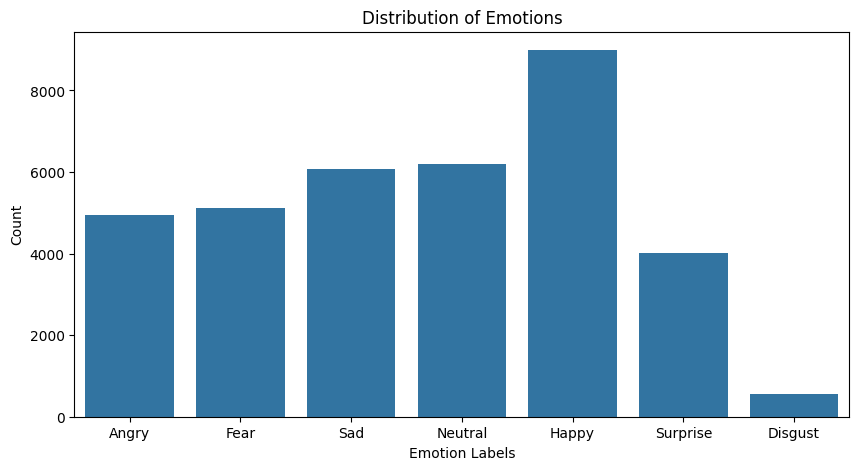

In [ ]:
# Emotion mapping
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Visualize Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df['emotion'].map(emotion_map))
plt.title('Distribution of Emotions')
plt.xlabel('Emotion Labels')
plt.ylabel('Count')
plt.show()

Sample images from the dataset:


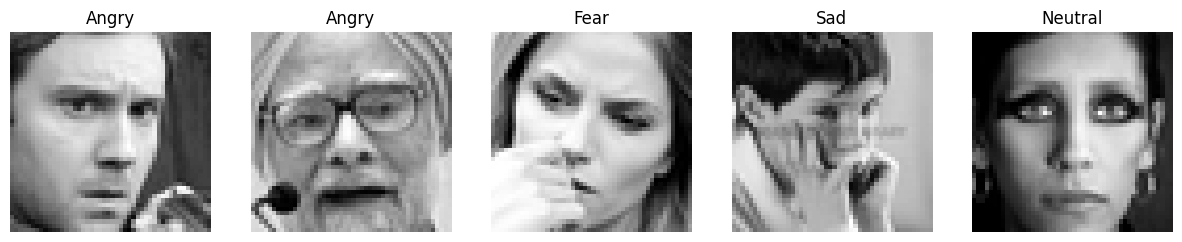

In [ ]:
def plot_samples(df, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):

        pixels = df.iloc[i][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(emotion_map[df.iloc[i]['emotion']])
        plt.axis('off')
    plt.show()

print("Sample images from the dataset:")
plot_samples(df)

### 1.2 Deep Dive into Data Structure
Let's look at the raw training data structure and the distribution of pixel intensities across all images.

Raw Pixel Data Example (First 50 characters of the first row):
70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119...


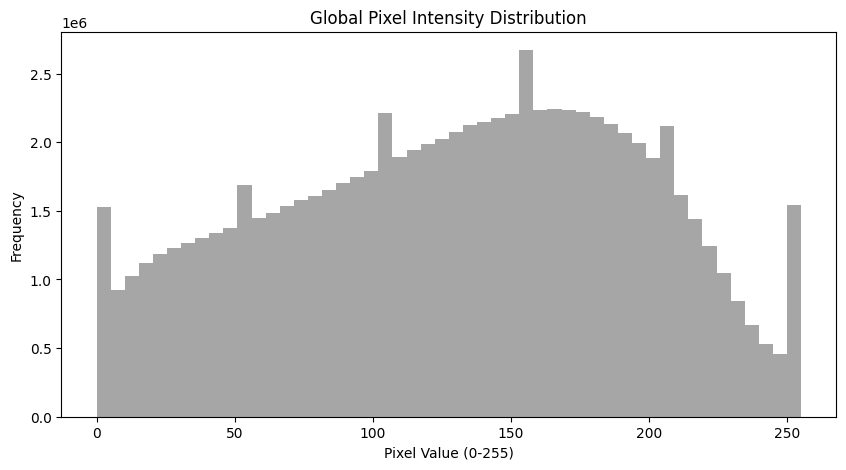

In [ ]:
print("Raw Pixel Data Example (First 50 characters of the first row):")
print(df.loc[0, ' pixels'][:50] + "...")

all_pixels = np.array([np.fromstring(x, dtype=int, sep=' ') for x in df[' pixels']])

plt.figure(figsize=(10, 5))
plt.hist(all_pixels.flatten(), bins=50, color='gray', alpha=0.7)

plt.title('Global Pixel Intensity Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.show()

## 2. Data Preparation
We will create a custom PyTorch Dataset to handle the conversion of pixel strings to tensors and apply basic normalization.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        pixels = self.df.iloc[idx][' pixels'].split()

        image = np.array(pixels, dtype='uint8').reshape(48, 48)
        label = int(self.df.iloc[idx]['emotion'])

        if self.transform:
            image = self.transform(image)

        return image, label

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Split the dataframe
train_df = df[df[' Usage'] == 'Training']
val_df = df[df[' Usage'] == 'PublicTest']

# Initialize Datasets
train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset = FERDataset(val_df, transform=val_transform)

# Create Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"DataLoaders created with data augmentation and {len(train_dataset)} training samples.")

DataLoaders created with data augmentation and 28709 training samples.


In [ ]:
import pandas as pd

# Verification of Data Split integrity
train_indices = set(train_df.index)
val_indices = set(val_df.index)

overlap = train_indices.intersection(val_indices)

print(f"Total Training samples: {len(train_df)}")
print(f"Total Validation samples: {len(val_df)}")
print(f"Number of overlapping samples: {len(overlap)}")

if len(overlap) == 0:
    print("SUCCESS: No data leakage. The sets are strictly independent.")
else:
    print("WARNING: Data leakage detected!")

Total Training samples: 28709
Total Validation samples: 3589
Number of overlapping samples: 0
SUCCESS: No data leakage. The sets are strictly independent.


## 3. Model Development
### ConvNeXt
In this version, we implement a ConvNeXt-Tiny model. ConvNeXt is a modern, pure-convolutional architecture that adopts successful design choices from Vision Transformers (like AdamW, LayerNorm, and inverted bottlenecks) while maintaining the efficiency of standard convolutions.

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

class ConvNeXtFER(nn.Module):
    def __init__(self, num_classes=7, dropout_prob=0.5):
        super(ConvNeXtFER, self).__init__()
        self.backbone = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        # Adjust first conv layer for 1-channel (grayscale) input
        self.backbone.features[0][0] = nn.Conv2d(1, 96, kernel_size=4, stride=4)

        n_inputs = self.backbone.classifier[2].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Flatten(start_dim=1, end_dim=-1),
            nn.LayerNorm((n_inputs,), eps=1e-06, elementwise_affine=True),
            nn.Dropout(p=dropout_prob),
            nn.Linear(n_inputs, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

def get_model(num_classes=7, dropout_prob=0.5):
    return ConvNeXtFER(num_classes, dropout_prob)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model().to(device)
print(f"ConvNeXt-Tiny initialized and fixed on: {device}")

ConvNeXt-Tiny initialized and fixed on: cuda


### 3.2 Define Loss Function and Optimizer
We will use CrossEntropyLoss (standard for classification) and the Adam optimizer.

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


### 3.4 Training Loop
We iterate through the training data, update the model weights, and log metrics to W&B.

In [ ]:
import matplotlib.pyplot as plt
import wandb
import torch
import torch.nn as nn
import torch.optim as optim

def train_sweep():
    with wandb.init() as run:
        config = run.config
        sweep_model = get_model(num_classes=7, dropout_prob=0.5).to(device)
        sweep_optimizer = optim.AdamW(sweep_model.parameters(), lr=config.learning_rate, weight_decay=0.05)
        sweep_train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
        sweep_val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

        num_epochs = 40
        for epoch in range(num_epochs):
            sweep_model.train()
            train_loss, train_correct, train_total = 0.0, 0, 0
            for images, labels in sweep_train_loader:
                images, labels = images.to(device), labels.to(device)
                sweep_optimizer.zero_grad()
                outputs = sweep_model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                sweep_optimizer.step()
                train_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                train_total += labels.size(0)
                train_correct += (pred == labels).sum().item()

            sweep_model.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for images, labels in sweep_val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = sweep_model(images)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    _, pred = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (pred == labels).sum().item()

            # Calculate final epoch metrics
            epoch_train_loss = train_loss / len(sweep_train_loader)
            epoch_train_acc = 100 * train_correct / train_total
            epoch_val_loss = val_loss / len(sweep_val_loader)
            epoch_val_acc = 100 * val_correct / val_total

            # Log to W&B with explicit keys for visualization
            wandb.log({
                "epoch": epoch + 1,
                "train/loss": epoch_train_loss,
                "train/accuracy": epoch_train_acc,
                "val/loss": epoch_val_loss,
                "val/accuracy": epoch_val_acc
            })

            print(f"Epoch {epoch+1}: T-Loss: {epoch_train_loss:.4f}, V-Loss: {epoch_val_loss:.4f}, T-Acc: {epoch_train_acc:.2f}%, V-Acc: {epoch_val_acc:.2f}%")

sweep_config = {
    'method': 'grid',
    'parameters': {
        'learning_rate': {"values": [0.0005]},
        'batch_size': {"values": [32]}
    }
}

sweep_id = wandb.sweep(sweep_config, project="facial-expression-recognition")
wandb.agent(sweep_id, function=train_sweep, count=2)

Create sweep with ID: 54aiyubq
Sweep URL: https://wandb.ai/gbera23-free-university-of-tbilisi-/facial-expression-recognition/sweeps/54aiyubq


wandb: Agent Starting Run: s1ldhu6f with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.0005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1: T-Loss: 1.8011, V-Loss: 1.5680, T-Acc: 25.86%, V-Acc: 39.37%
Epoch 2: T-Loss: 1.5117, V-Loss: 1.3436, T-Acc: 41.31%, V-Acc: 48.65%
Epoch 3: T-Loss: 1.3660, V-Loss: 1.2739, T-Acc: 47.36%, V-Acc: 51.52%
Epoch 4: T-Loss: 1.2862, V-Loss: 1.2043, T-Acc: 50.74%, V-Acc: 54.58%
Epoch 5: T-Loss: 1.2439, V-Loss: 1.1971, T-Acc: 52.44%, V-Acc: 54.30%
Epoch 6: T-Loss: 1.1980, V-Loss: 1.1519, T-Acc: 54.65%, V-Acc: 57.15%
Epoch 7: T-Loss: 1.1687, V-Loss: 1.1566, T-Acc: 56.00%, V-Acc: 56.90%
Epoch 8: T-Loss: 1.1394, V-Loss: 1.1305, T-Acc: 56.97%, V-Acc: 57.37%
Epoch 9: T-Loss: 1.1169, V-Loss: 1.1288, T-Acc: 57.94%, V-Acc: 56.87%
Epoch 10: T-Loss: 1.0996, V-Loss: 1.0921, T-Acc: 58.33%, V-Acc: 59.35%
Epoch 11: T-Loss: 1.0769, V-Loss: 1.1106, T-Acc: 59.35%, V-Acc: 58.34%
Epoch 12: T-Loss: 1.0578, V-Loss: 1.0696, T-Acc: 59.97%, V-Acc: 59.63%
Epoch 13: T-Loss: 1.0413, V-Loss: 1.0859, T-Acc: 60.67%, V-Acc: 59.63%
Epoch 14: T-Loss: 1.0272, V-Loss: 1.0616, T-Acc: 61.12%, V-Acc: 60.49%
Epoch 15: T-Los

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/accuracy,▁▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████
train/loss,█▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val/accuracy,▁▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██▇██████▇█████████
val/loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▂▁▂▂▂
epoch,40
train/accuracy,75.59302
train/loss,0.66115
val/accuracy,63.88966
val/loss,1.07797


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


In [ ]:
import wandb
import torch
import os
import json

project_name = "facial-expression-recognition"
run_id = "s1ldhu6f"
model_source = "model_files/best_model.pth"
artifact_dir = "pipeline_bundle"
os.makedirs(artifact_dir, exist_ok=True)

if os.path.exists(model_source):
    torch.save(torch.load(model_source), os.path.join(artifact_dir, "model.pth"))

    config = {
        "preprocessing": {"resize": [48, 48], "to_tensor": True, "normalize": {"mean": [0.5], "std": [0.5]}},
        "input_channels": 1,
        "num_classes": 7
    }
    with open(os.path.join(artifact_dir, "preprocessor_config.json"), "w") as f:
        json.dump(config, f)

    run = wandb.init(project=project_name, id=run_id, resume="must")
    art = wandb.Artifact(name="fer_pipeline", type="pipeline")
    art.add_dir(artifact_dir)
    run.log_artifact(art)
    run.finish()
    print("Pipeline artifact logged successfully.")
else:
    print(f"File {model_source} not found.")